## Question 9 - *Correlation between CPU peaks and task evictions*

**Method / definitions.**
- Define machine-window key: `(machine_id, window_start)` where `window_start` is the task_usage start time.
- Compute:
  - `cpu_sum(machine, window)`: sum of CPU usage across tasks on that machine during the window.
  - `evict_count(machine, window)`: number of eviction events mapped into the same 5-min bucket.
- Define **peak windows** as top 5% windows by `cpu_sum` (95th percentile threshold).
- Compare eviction activity in peak vs non-peak windows and compute Pearson correlation between `cpu_sum` and `evict_count`.

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/01/14 23:22:22 WARN Utils: Your hostname, im2ag-mandelbrot, resolves to a loopback address: 127.0.1.1; using 152.77.81.20 instead (on interface ens18)
26/01/14 23:22:22 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/01/14 23:22:22 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


Usage machine-windows: 2120388
Eviction machine-windows: 26312


Joined windows: 2120740


Approx CPU 95th percentile threshold (cpu_sum): 0.409922254



--- Peak vs Non-Peak ---
Peak windows: 102430  Non-peak windows: 2018310
P(eviction>0 | peak)   = 0.02575417358195841
P(eviction>0 | nonpeak)= 0.011729615371275969
Avg evictions/window (peak)   = 0.04142341111002635
Avg evictions/window (nonpeak)= 0.019147207317012995

Pearson correlation (cpu_sum vs eviction_count): 0.07170762623003066


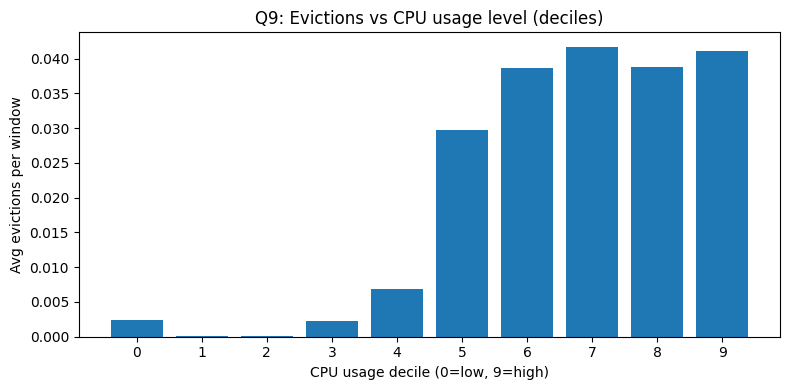

In [1]:
import sys
from pyspark.sql import SparkSession
import matplotlib.pyplot as plt
import numpy as np
from pyspark.sql import functions as F
import time
from pyspark.storagelevel import StorageLevel
import pandas as pd

spark = SparkSession.builder.getOrCreate()
sc = spark.sparkContext

PATH_MACHINE_EVENTS = "./data/machine_events/*.csv.gz"
PATH_JOB_EVENTS  = "./data/job_events/*.csv.gz"
PATH_TASK_EVENTS = "./data/task_events/*.csv.gz"
PATH_TASK_USAGE = "./data/task_usage/*.csv.gz"

# ----------------------------
# Parsing utilities
# ----------------------------
def to_int(x):
    return int(x) if x not in (None, "", "NULL") else None

def to_long(x):
    return int(x) if x not in (None, "", "NULL") else None

def to_float(x):
    return float(x) if x not in (None, "", "NULL") else None

EVICT = 2
WINDOW_US = 5 * 60 * 1_000_000  # 5 minutes in microseconds

# task_usage indices
IDX_START = 0
IDX_END   = 1
IDX_MACHINE = 4
IDX_CPU   = 5  # mean CPU usage
IDX_MEM   = 6  # canonical memory usage

def floor_to_window(ts_us, window_us=WINDOW_US):
    return ts_us - (ts_us % window_us)

# ----------------------------
# Parse task_usage
# ----------------------------
def parse_task_usage(line):
    p = line.split(",")
    if len(p) <= max(IDX_MEM, IDX_CPU, IDX_MACHINE, IDX_END):
        return None

    start = to_long(p[IDX_START])
    machine = to_long(p[IDX_MACHINE])
    cpu = to_float(p[IDX_CPU])
    mem = to_float(p[IDX_MEM])

    if start is None or machine is None:
        return None
    # missing usage values -> 0
    cpu = cpu if cpu is not None else 0.0
    mem = mem if mem is not None else 0.0

    return ((machine, start), (cpu, mem, 1))

task_usage = sc.textFile(PATH_TASK_USAGE).map(parse_task_usage).filter(lambda x: x is not None)

# Aggregate machine usage per window
usage_by_machine_window = (
    task_usage
    .reduceByKey(lambda a,b: (a[0]+b[0], a[1]+b[1], a[2]+b[2]))
    .cache()
)

print("Usage machine-windows:", usage_by_machine_window.count())

# ----------------------------
# Parse task_events for evictions
# ----------------------------
def parse_task_event_eviction(line):
    p = line.split(",")
    if len(p) < 6:
        return None

    ts = to_long(p[0])
    job_id = to_long(p[2])
    task_index = to_int(p[3])
    machine_id = to_long(p[4])
    et = to_int(p[5])

    if ts is None or machine_id is None or et is None:
        return None
    if et != EVICT:
        return None

    wstart = floor_to_window(ts)
    return ((machine_id, wstart), 1)

evictions_by_machine_window = (
    sc.textFile(PATH_TASK_EVENTS)
    .map(parse_task_event_eviction)
    .filter(lambda x: x is not None)
    .reduceByKey(lambda a,b: a+b)
    .cache()
)

print("Eviction machine-windows:", evictions_by_machine_window.count())

# ----------------------------
# Join usage with evictions
# ----------------------------
joined = (
    usage_by_machine_window
    .cogroup(evictions_by_machine_window)
    .mapValues(lambda x: (list(x[0]), list(x[1])))
    .mapValues(lambda lists: (
        lists[0][0] if lists[0] else (0.0, 0.0, 0),
        lists[1][0] if lists[1] else 0
    ))
    .cache()
)

print("Joined windows:", joined.count())

# Flatten for analysis
cpu_evict = joined.map(lambda x: (x[1][0][0], x[1][1])).cache()

# ----------------------------
# Peak threshold using sampling
# ----------------------------
sample = cpu_evict.map(lambda x: x[0]).sample(False, 0.02, seed=42).collect()  # 2% sample
sample = [v for v in sample if v is not None]
cpu_p95 = float(np.quantile(sample, 0.95)) if sample else 0.0

print("Approx CPU 95th percentile threshold (cpu_sum):", cpu_p95)

# ----------------------------
# Compare eviction behavior: peak vs non-peak
# ----------------------------
peak = cpu_evict.filter(lambda x: x[0] >= cpu_p95)
nonpeak = cpu_evict.filter(lambda x: x[0] < cpu_p95)

peak_n = peak.count()
nonpeak_n = nonpeak.count()

peak_evicted_windows = peak.filter(lambda x: x[1] > 0).count()
nonpeak_evicted_windows = nonpeak.filter(lambda x: x[1] > 0).count()

peak_rate = (peak_evicted_windows / peak_n) if peak_n else 0.0
nonpeak_rate = (nonpeak_evicted_windows / nonpeak_n) if nonpeak_n else 0.0

peak_avg_evict = peak.map(lambda x: x[1]).mean() if peak_n else 0.0
nonpeak_avg_evict = nonpeak.map(lambda x: x[1]).mean() if nonpeak_n else 0.0

print("\n--- Peak vs Non-Peak ---")
print("Peak windows:", peak_n, " Non-peak windows:", nonpeak_n)
print("P(eviction>0 | peak)   =", peak_rate)
print("P(eviction>0 | nonpeak)=", nonpeak_rate)
print("Avg evictions/window (peak)   =", peak_avg_evict)
print("Avg evictions/window (nonpeak)=", nonpeak_avg_evict)

# ----------------------------
# Pearson correlation between cpu_sum and eviction_count
# ----------------------------
def seq_op(acc, xy):
    n, sx, sy, sxx, syy, sxy = acc
    x, y = xy
    n += 1
    sx += x
    sy += y
    sxx += x*x
    syy += y*y
    sxy += x*y
    return (n, sx, sy, sxx, syy, sxy)

def comb_op(a, b):
    return tuple(a[i] + b[i] for i in range(6))

n, sx, sy, sxx, syy, sxy = cpu_evict.aggregate((0,0.0,0.0,0.0,0.0,0.0), seq_op, comb_op)

num = n * sxy - sx * sy
den = ((n * sxx - sx*sx) ** 0.5) * ((n * syy - sy*sy) ** 0.5)
pearson = (num / den) if den != 0 else 0.0

print("\nPearson correlation (cpu_sum vs eviction_count):", pearson)

# ----------------------------
# Plot: average evictions by CPU usage decile (optional)
# ----------------------------
# Build deciles from a sample and bucket windows accordingly
dec_sample = cpu_evict.map(lambda x: x[0]).sample(False, 0.02, seed=7).collect()
dec_sample = [v for v in dec_sample if v is not None]
qs = [float(np.quantile(dec_sample, q)) for q in np.linspace(0, 1, 11)] if dec_sample else [0.0]*11

def decile_bucket(x):
    # returns 0..9
    for i in range(10):
        if x <= qs[i+1]:
            return i
    return 9

binned = cpu_evict.map(lambda x: (decile_bucket(x[0]), (x[1], 1)))
dec_stats = (
    binned.reduceByKey(lambda a,b: (a[0]+b[0], a[1]+b[1]))
          .mapValues(lambda s: s[0]/s[1] if s[1] else 0.0)
          .collect()
)
dec_stats = sorted(dec_stats, key=lambda x: x[0])

xs = [d for d,_ in dec_stats]
ys = [v for _,v in dec_stats]

plt.figure(figsize=(8,4))
plt.bar([str(x) for x in xs], ys)
plt.xlabel("CPU usage decile (0=low, 9=high)")
plt.ylabel("Avg evictions per window")
plt.title("Q9: Evictions vs CPU usage level (deciles)")
plt.tight_layout()
# plt.savefig("../figures/q9_evictions_vs_cpu_deciles.png", dpi=300, bbox_inches="tight")
plt.show()

**Results (subset).**
- Usage windows: **2,099,250**
- Windows with ≥1 eviction: **26,312**
- Joined windows: **2,101,869**
- CPU 95th percentile threshold: `cpu_sum ≈ 0.4095`

Peak vs non-peak:
- Peak windows: **103,781**
- Non-peak windows: **1,998,088**
- `P(eviction>0 | peak)` = **0.02255** (2.255%)
- `P(eviction>0 | non-peak)` = **0.011997** (1.200%)
- Avg evictions/window: peak **0.03642**, non-peak **0.01957**
- Pearson correlation: **r = 0.0556**

**Interpretation.**
- Evictions are about **~1.9× more likely** during peak CPU windows than during non-peak windows.
- The Pearson correlation is small but positive, meaning CPU load alone is not a strong linear predictor.
- Overall, results suggest that resource pressure increases eviction probability, but evictions also depend on other factors (priority, scheduling class, memory pressure, policies).